<a href="https://colab.research.google.com/github/Harini162006/harini-codebooster-2026/blob/main/Day%207/phase1Finale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df=pd.read_csv('student_performance.csv')
print(f"Database loaded:{df.shape[0]} students,{df.shape[1]} columns")
print(f"Columns {df.columns.tolist()}")


Database loaded:30 students,13 columns
Columns ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [ ]:
conn=sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql("students", conn, if_exists="replace", index=False)


30

In [ ]:
def run_query(sql,description=''):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

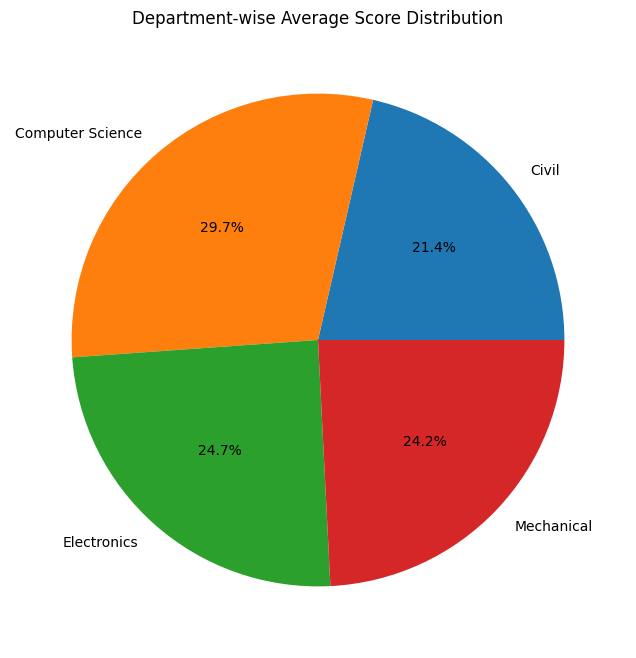

In [ ]:
import matplotlib.pyplot as plt

dept_avg = df.groupby('department')[['math_score', 'science_score', 'english_score','programming_score','attendance_percentage']].mean().mean(axis=1)

plt.figure(figsize=(8, 8))

plt.pie(
    dept_avg.values,
    labels=dept_avg.index,
    autopct='%1.1f%%'
)

plt.title('Department-wise Average Score Distribution')

plt.show()

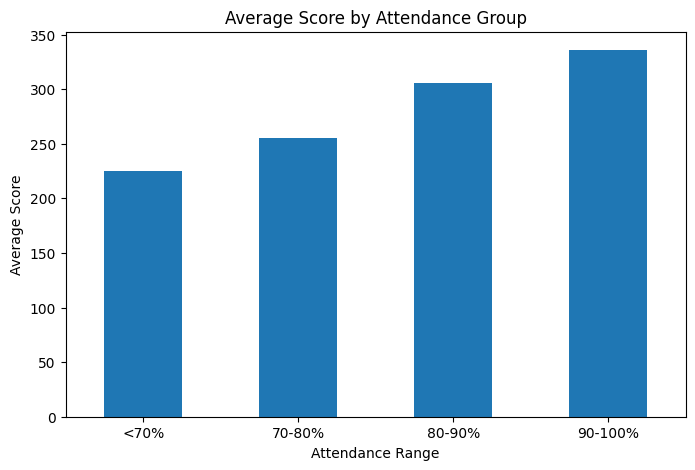

In [ ]:
df['attendance_group'] = pd.cut(
    df['attendance_percentage'],
    bins=[0,70,80,90,100],
    labels=[
        '<70%',
        '70-80%',
        '80-90%',
        '90-100%'
    ]
)

avg_scores = df.groupby(
    'attendance_group'
)['total_score'].mean()

avg_scores.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Average Score by Attendance Group'
)

plt.xlabel('Attendance Range')
plt.ylabel('Average Score')
plt.xticks(rotation=0)

plt.show()